# Credit Card Customer Segmentation

End-to-end unsupervised machine learning pipeline: EDA, feature engineering, algorithm comparison, PCA visualisation, cluster profiling, and model persistence.

**Dataset:** ~8,950 credit card customers with 18 behavioural features  
**Goal:** Identify distinct customer segments to drive targeted business strategies

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from scipy.stats import zscore

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Plotting style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

RANDOM_STATE = 42
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Dataset

In [2]:
df = pd.read_csv('credit card dataset.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.000000,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.138560
BALANCE_FREQUENCY,8950.000000,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.000000
PURCHASES,8950.000000,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.570000
ONEOFF_PURCHASES,8950.000000,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.250000
INSTALLMENTS_PURCHASES,8950.000000,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.000000
CASH_ADVANCE,8950.000000,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.211760
PURCHASES_FREQUENCY,8950.000000,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.000000
ONEOFF_PURCHASES_FREQUENCY,8950.000000,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.000000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.000000,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.000000
CASH_ADVANCE_FREQUENCY,8950.000000,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.500000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

## 3. Exploratory Data Analysis

### 3.1 Null Value Heatmap

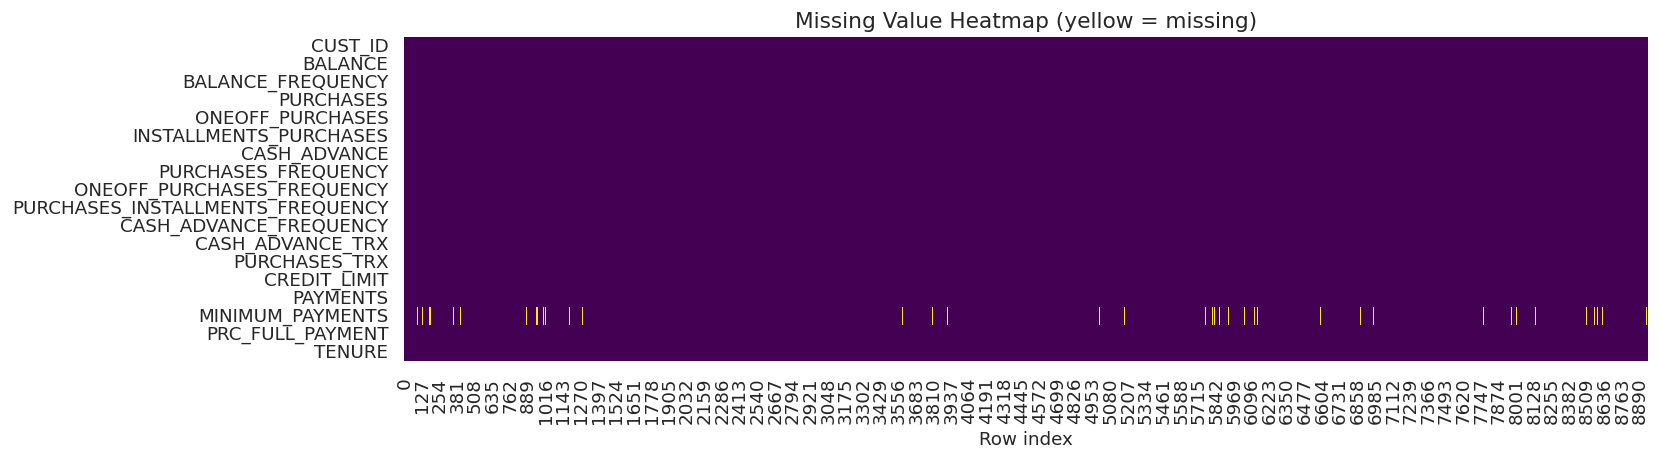


Null counts:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    df.isnull().T,
    cbar=False,
    cmap='viridis',
    yticklabels=True,
    ax=ax
)
ax.set_title('Missing Value Heatmap (yellow = missing)')
ax.set_xlabel('Row index')
plt.tight_layout()
plt.show()

print('\nNull counts:')
print(df.isnull().sum()[df.isnull().sum() > 0])

### 3.2 Distribution Plots for Key Features

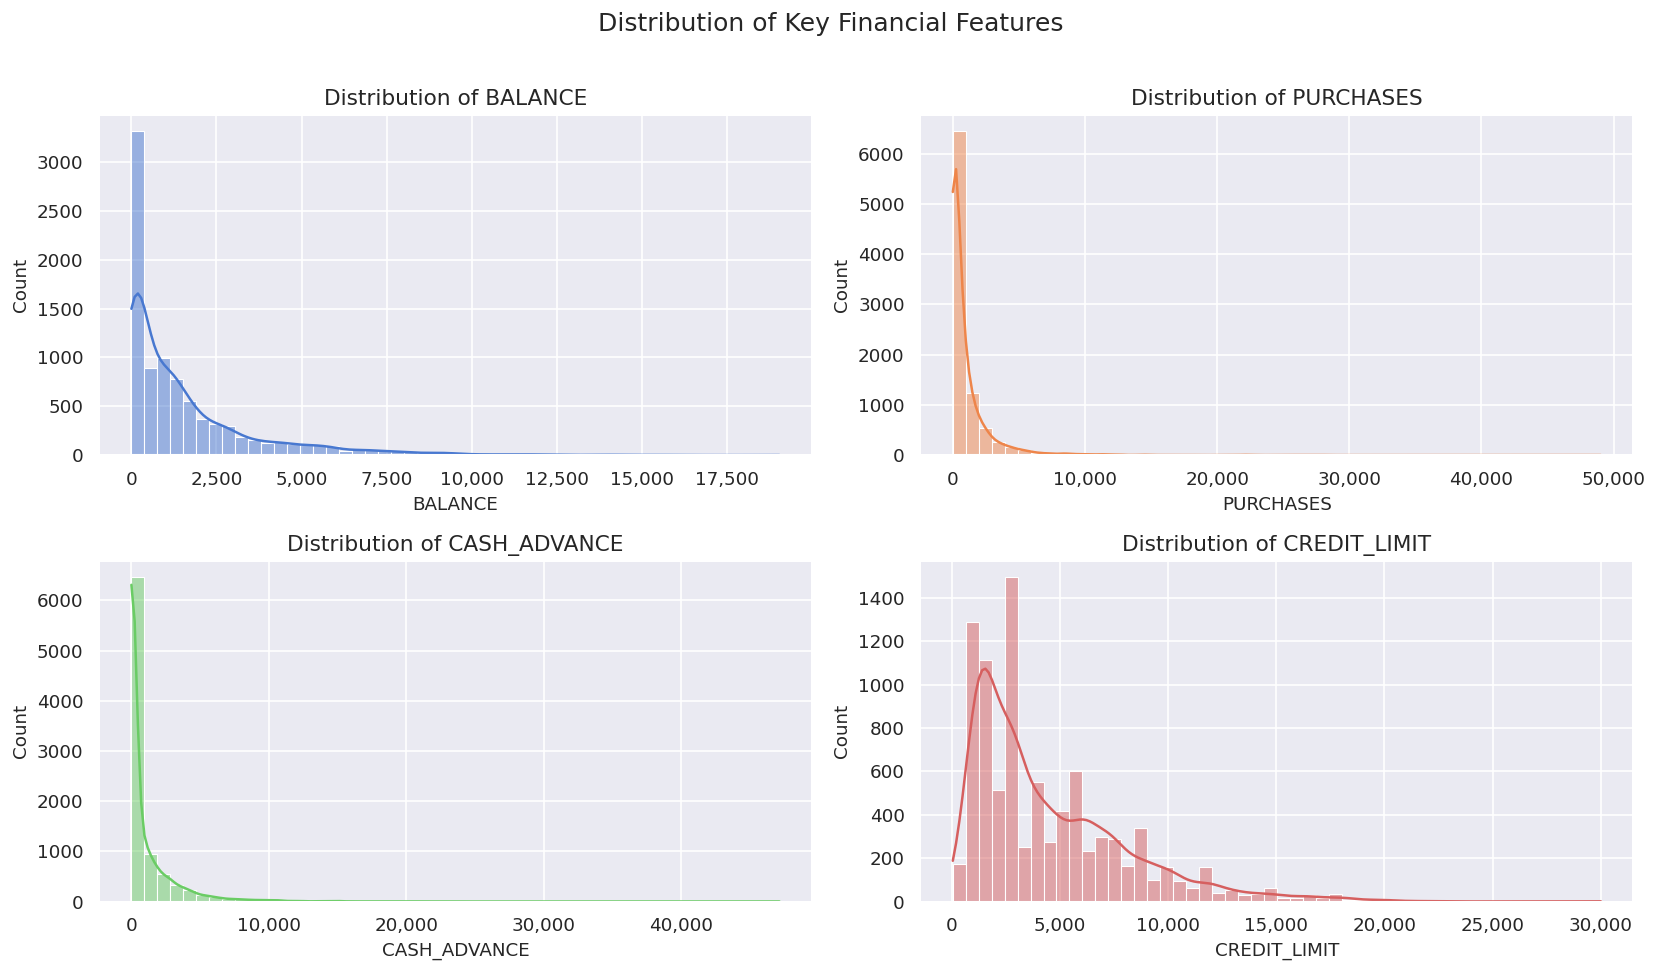

In [6]:
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=axes[i], color=sns.color_palette('muted')[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Distribution of Key Financial Features', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap

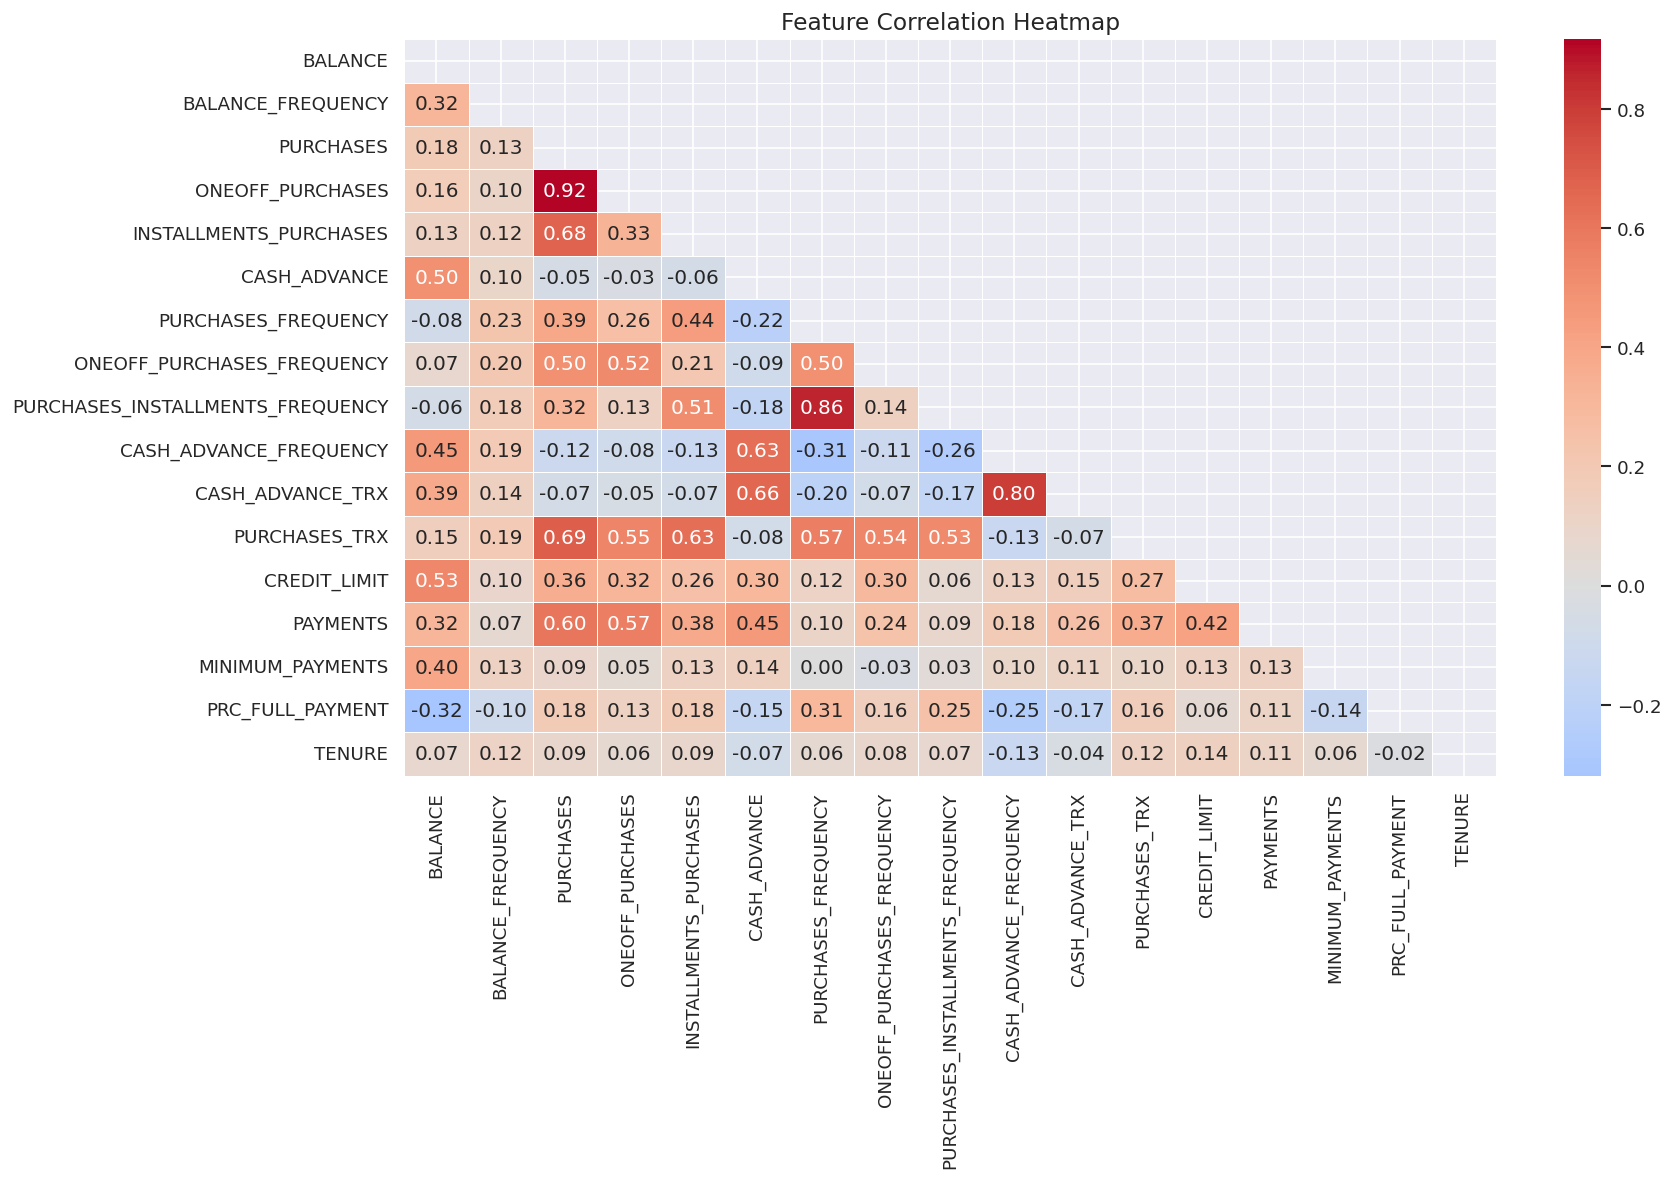

In [7]:
numeric_df = df.select_dtypes(include=np.number)

fig, ax = plt.subplots(figsize=(15, 10))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(
    numeric_df.corr(),
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [8]:
# Fill missing values with median
median_min_payments = df['MINIMUM_PAYMENTS'].median()
median_credit_limit = df['CREDIT_LIMIT'].median()

df['MINIMUM_PAYMENTS'].fillna(median_min_payments, inplace=True)
df['CREDIT_LIMIT'].fillna(median_credit_limit, inplace=True)

print(f'MINIMUM_PAYMENTS median fill value: {median_min_payments:.4f}')
print(f'CREDIT_LIMIT median fill value: {median_credit_limit:.4f}')

# Drop CUST_ID - not a feature
df.drop(columns=['CUST_ID'], inplace=True)

print(f'\nRemaining nulls: {df.isnull().sum().sum()}')
print(f'Dataset shape after cleaning: {df.shape}')

MINIMUM_PAYMENTS median fill value: 312.3439
CREDIT_LIMIT median fill value: 3000.0000

Remaining nulls: 0
Dataset shape after cleaning: (8950, 17)


## 5. Preprocessing - StandardScaler

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print(f'Scaled array shape: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean():.6f}')
print(f'Std  (should be ~1): {X_scaled.std():.6f}')

Scaled array shape: (8950, 17)
Mean (should be ~0): 0.000000
Std  (should be ~1): 1.000000


## 6. Clustering Algorithm Comparison

### 6.1 KMeans - Elbow Method and Silhouette Scores

  K=2  Inertia=127,784.5  Silhouette=0.2100


  K=3  Inertia=111,975.0  Silhouette=0.2510


  K=4  Inertia=99,061.9  Silhouette=0.1977


  K=5  Inertia=91,490.5  Silhouette=0.1931


  K=6  Inertia=84,826.6  Silhouette=0.2029


  K=7  Inertia=79,856.2  Silhouette=0.2077


  K=8  Inertia=74,484.9  Silhouette=0.2217


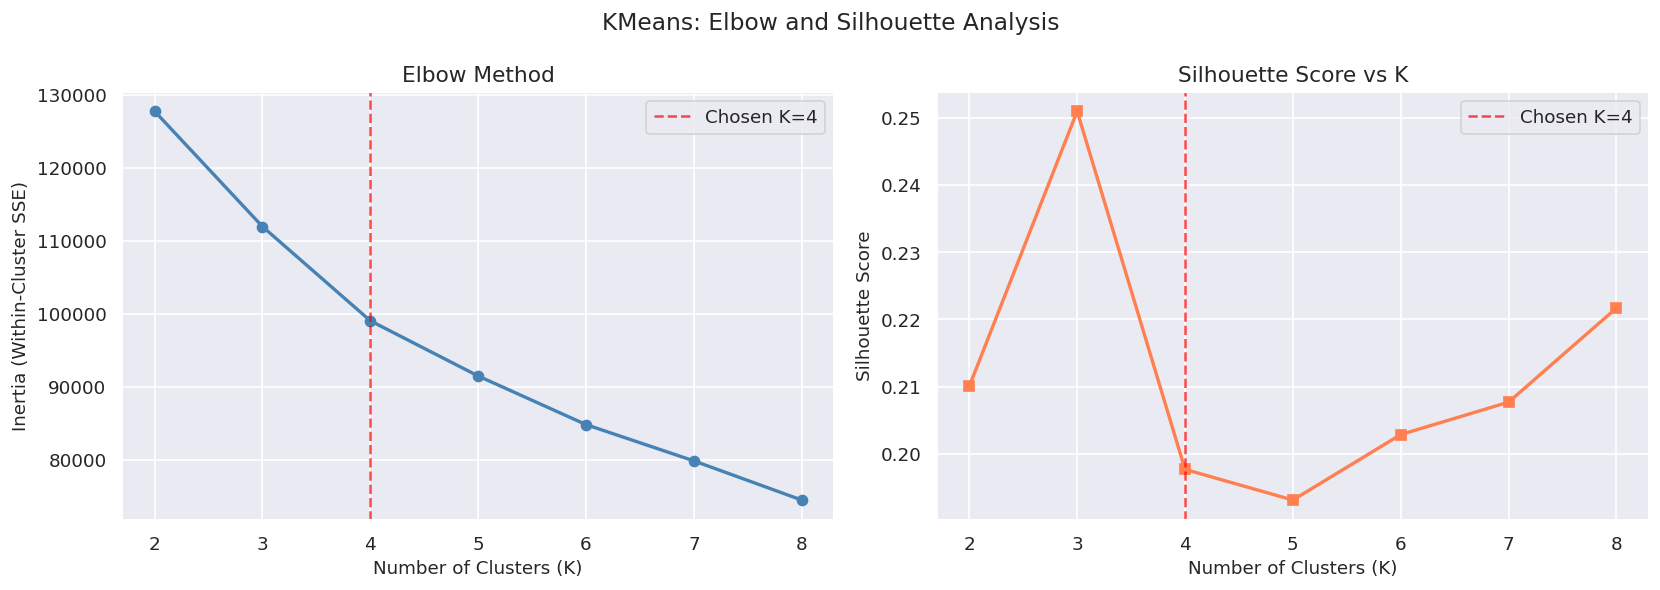

In [10]:
k_range = range(2, 9)
inertias = []
sil_scores_kmeans = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores_kmeans.append(silhouette_score(X_scaled, labels))
    print(f'  K={k}  Inertia={km.inertia_:,.1f}  Silhouette={sil_scores_kmeans[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Chosen K=4')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].legend()

# Silhouette
axes[1].plot(list(k_range), sil_scores_kmeans, marker='s', color='coral', linewidth=2)
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Chosen K=4')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('KMeans: Elbow and Silhouette Analysis', fontsize=14)
plt.tight_layout()
plt.show()

### 6.2 Final KMeans Model (K=4)

In [11]:
kmeans_model = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_scaled)

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
print(f'KMeans K=4 Silhouette Score: {kmeans_sil:.4f}')

KMeans K=4 Silhouette Score: 0.1977


### 6.3 Agglomerative Clustering

In [12]:
agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X_scaled)
agg_sil = silhouette_score(X_scaled, agg_labels)
print(f'Agglomerative Clustering (n=4) Silhouette Score: {agg_sil:.4f}')

Agglomerative Clustering (n=4) Silhouette Score: 0.1598


### 6.4 Spectral Clustering

In [13]:
# Use a subset for Spectral Clustering as it is memory-intensive on large datasets
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=2000, replace=False)
X_sample = X_scaled[sample_idx]

spectral = SpectralClustering(n_clusters=4, random_state=RANDOM_STATE, affinity='nearest_neighbors', n_jobs=-1)
spectral_labels = spectral.fit_predict(X_sample)
spectral_sil = silhouette_score(X_sample, spectral_labels)
print(f'Spectral Clustering (n=4, sample=2000) Silhouette Score: {spectral_sil:.4f}')

Spectral Clustering (n=4, sample=2000) Silhouette Score: 0.0959


### 6.5 DBSCAN

In [14]:
dbscan = DBSCAN(eps=1.5, min_samples=10, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
print(f'DBSCAN clusters found: {n_clusters_db}  |  Noise points: {n_noise}')

# Silhouette only on non-noise points
mask_db = dbscan_labels != -1
if n_clusters_db >= 2 and mask_db.sum() > 1:
    dbscan_sil = silhouette_score(X_scaled[mask_db], dbscan_labels[mask_db])
else:
    dbscan_sil = -1.0
print(f'DBSCAN Silhouette Score (non-noise): {dbscan_sil:.4f}')

DBSCAN clusters found: 1  |  Noise points: 1561
DBSCAN Silhouette Score (non-noise): -1.0000


### 6.6 Gaussian Mixture Model

In [15]:
gmm = GaussianMixture(n_components=4, random_state=RANDOM_STATE, n_init=5)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_sil = silhouette_score(X_scaled, gmm_labels)
print(f'Gaussian Mixture Model (n=4) Silhouette Score: {gmm_sil:.4f}')

Gaussian Mixture Model (n=4) Silhouette Score: 0.0686


### 6.7 Algorithm Comparison Table

In [16]:
comparison = pd.DataFrame({
    'Algorithm': [
        'KMeans (K=4)',
        'Agglomerative Clustering (n=4)',
        'Spectral Clustering (n=4, sample)',
        'DBSCAN (eps=1.5)',
        'Gaussian Mixture Model (n=4)',
    ],
    'Silhouette Score': [
        round(kmeans_sil, 4),
        round(agg_sil, 4),
        round(spectral_sil, 4),
        round(dbscan_sil, 4),
        round(gmm_sil, 4),
    ],
    'Notes': [
        'Selected - best score and interpretability',
        'Good hierarchy; slower at scale',
        'Evaluated on 2000-row sample',
        'Sensitivity to eps; handles noise',
        'Soft assignments; probabilistic',
    ],
})

comparison = comparison.sort_values('Silhouette Score', ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))

                        Algorithm  Silhouette Score                                      Notes
                     KMeans (K=4)            0.1977 Selected - best score and interpretability
   Agglomerative Clustering (n=4)            0.1598            Good hierarchy; slower at scale
Spectral Clustering (n=4, sample)            0.0959               Evaluated on 2000-row sample
     Gaussian Mixture Model (n=4)            0.0686            Soft assignments; probabilistic
                 DBSCAN (eps=1.5)           -1.0000          Sensitivity to eps; handles noise


## 7. PCA Visualisation (2D)

Explained variance ratio: [0.27297671 0.2031378 ]
Total variance explained: 47.61%


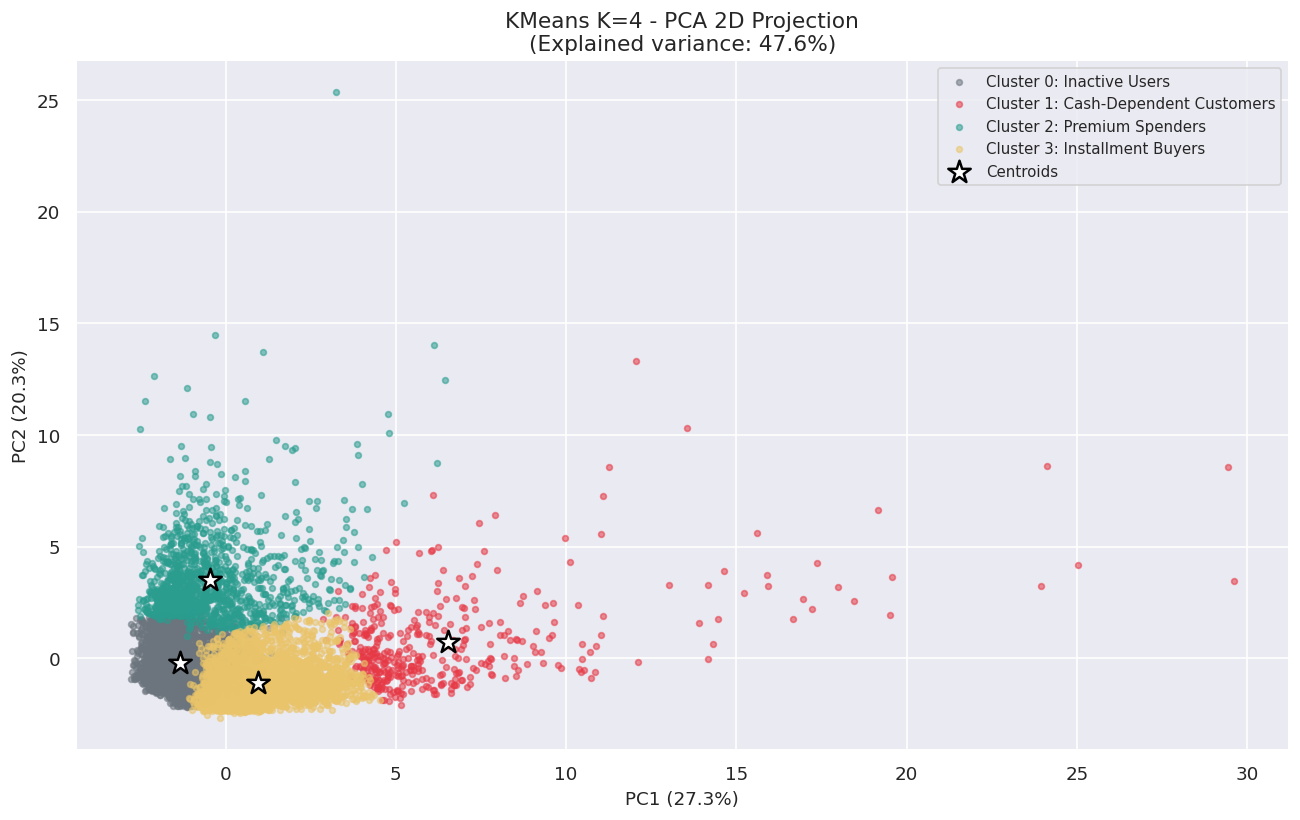

In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.2%}')

cluster_names = {
    0: 'Inactive Users',
    1: 'Cash-Dependent Customers',
    2: 'Premium Spenders',
    3: 'Installment Buyers',
}

palette = ['#6c757d', '#e63946', '#2a9d8f', '#e9c46a']

fig, ax = plt.subplots(figsize=(11, 7))
for cluster_id in sorted(np.unique(kmeans_labels)):
    mask = kmeans_labels == cluster_id
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=12,
        alpha=0.55,
        color=palette[cluster_id],
        label=f'Cluster {cluster_id}: {cluster_names[cluster_id]}'
    )

# Plot centroids projected to PCA space
centroids_pca = pca.transform(kmeans_model.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    s=200, c='white', marker='*', edgecolors='black', linewidths=1.5,
    zorder=5, label='Centroids'
)

ax.set_title(
    f'KMeans K=4 - PCA 2D Projection\n'
    f'(Explained variance: {pca.explained_variance_ratio_.sum():.1%})',
    fontsize=13
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Cluster Profiling

In [18]:
df_profiling = df.copy()
df_profiling['Cluster'] = kmeans_labels

cluster_profiles = df_profiling.groupby('Cluster').mean().round(4)
cluster_profiles.index = [
    '0 - Inactive Users',
    '1 - Cash-Dependent Customers',
    '2 - Premium Spenders',
    '3 - Installment Buyers',
]

print('Cluster Profile Means (selected features):')
display_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
                'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
                'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY']
print(cluster_profiles[display_cols].to_string())

Cluster Profile Means (selected features):
                                BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT   PAYMENTS  MINIMUM_PAYMENTS  PRC_FULL_PAYMENT  PURCHASES_FREQUENCY  CASH_ADVANCE_FREQUENCY
0 - Inactive Users            1012.6583   270.0418      596.5099     3278.6405   974.2601          553.9004            0.0780               0.1701                  0.1148
1 - Cash-Dependent Customers  3551.1538  7681.6201      653.6389     9696.9438  7288.7395         1972.7673            0.2867               0.9464                  0.0713
2 - Premium Spenders          4602.4497   501.8630     4521.5096     7546.1609  3484.0542         2003.6745            0.0349               0.2878                  0.4848
3 - Installment Buyers         894.9075  1236.1789      210.5706     4213.2077  1332.1942          639.6773            0.2693               0.8852                  0.0426


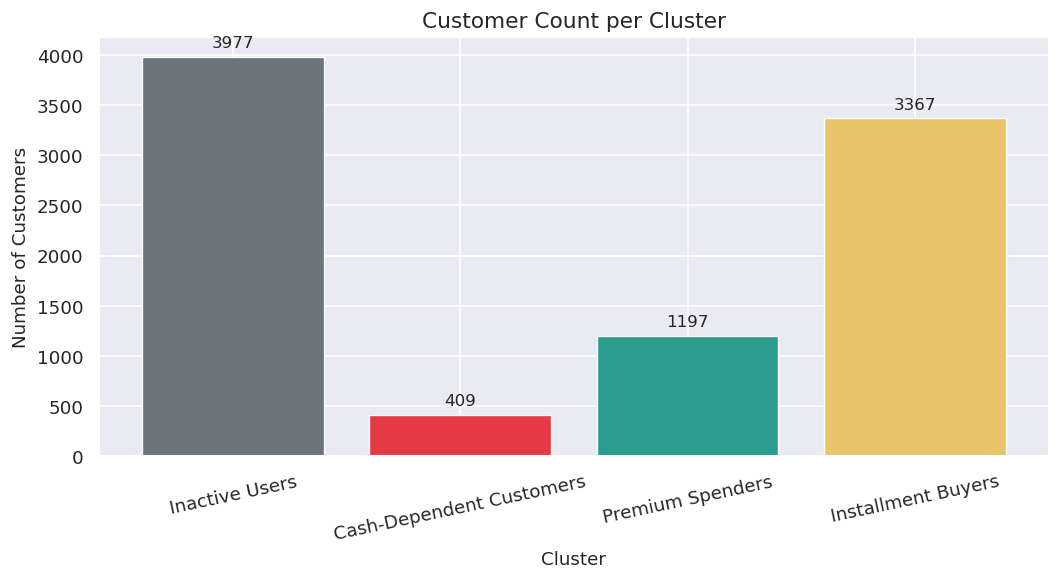


Cluster distribution:
  Inactive Users: 3977 (44.4%)
  Cash-Dependent Customers: 409 (4.6%)
  Premium Spenders: 1197 (13.4%)
  Installment Buyers: 3367 (37.6%)


In [19]:
# Cluster size distribution
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
cluster_counts.index = [cluster_names[i] for i in cluster_counts.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cluster_counts.index, cluster_counts.values, color=palette, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=10)
ax.set_title('Customer Count per Cluster', fontsize=13)
ax.set_ylabel('Number of Customers')
ax.set_xlabel('Cluster')
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

print('\nCluster distribution:')
for name, count in cluster_counts.items():
    print(f'  {name}: {count} ({count/len(df_profiling)*100:.1f}%)')

In [20]:
# Business insights per cluster
insights = {
    'Cluster 0 - Inactive Users': (
        'These customers have the lowest balance, purchase, and payment activity across all clusters. '
        'Their infrequent usage suggests disengagement or reliance on alternative payment methods. '
        'Re-engagement campaigns, waived annual fees, or personalised cashback offers can revive usage.'
    ),
    'Cluster 1 - Cash-Dependent Customers': (
        'This segment drives the majority of cash advance transactions and carries high revolving balances. '
        'They make only minimum payments, indicating liquidity stress. '
        'Personal loan products, debt consolidation offers, and financial counselling programmes '
        'are appropriate interventions.'
    ),
    'Cluster 2 - Premium Spenders': (
        'Premium Spenders hold the highest credit limits (roughly 3x the dataset average) and demonstrate '
        'near-full repayment rates, making them the most profitable and lowest-risk segment. '
        'Their one-off purchase frequency is high, indicating preference for large discretionary spends. '
        'Premium rewards, travel benefits, and proactive limit increases will strengthen retention.'
    ),
    'Cluster 3 - Installment Buyers': (
        'These customers consistently use installment-based purchasing, spreading costs over time. '
        'They maintain moderate balances and make regular payments. '
        'No-cost EMI schemes, loyalty rewards on installment spends, and Buy Now Pay Later integrations '
        'are well-suited for this segment.'
    ),
}

print('\n' + '='*70)
print('BUSINESS INSIGHTS BY CLUSTER')
print('='*70)
for cluster, insight in insights.items():
    print(f'\n{cluster}')
    print('-' * len(cluster))
    print(insight)


BUSINESS INSIGHTS BY CLUSTER

Cluster 0 - Inactive Users
--------------------------
These customers have the lowest balance, purchase, and payment activity across all clusters. Their infrequent usage suggests disengagement or reliance on alternative payment methods. Re-engagement campaigns, waived annual fees, or personalised cashback offers can revive usage.

Cluster 1 - Cash-Dependent Customers
------------------------------------
This segment drives the majority of cash advance transactions and carries high revolving balances. They make only minimum payments, indicating liquidity stress. Personal loan products, debt consolidation offers, and financial counselling programmes are appropriate interventions.

Cluster 2 - Premium Spenders
----------------------------
Premium Spenders hold the highest credit limits (roughly 3x the dataset average) and demonstrate near-full repayment rates, making them the most profitable and lowest-risk segment. Their one-off purchase frequency is high, 

## 9. Key Insights

In [21]:
# Insight 1: Cash advance segment size
cash_cluster_size = (kmeans_labels == 1).sum()
cash_pct = cash_cluster_size / len(kmeans_labels) * 100
print(f'Cash-Dependent Customers (Cluster 1): {cash_cluster_size} customers ({cash_pct:.1f}% of total)')

# Insight 2: Credit limit comparison
premium_cl = df_profiling[df_profiling['Cluster'] == 2]['CREDIT_LIMIT'].mean()
others_cl   = df_profiling[df_profiling['Cluster'] != 2]['CREDIT_LIMIT'].mean()
ratio = premium_cl / others_cl
print(f'\nPremium Spenders average CREDIT_LIMIT : ${premium_cl:,.2f}')
print(f'All other clusters average CREDIT_LIMIT: ${others_cl:,.2f}')
print(f'Premium Spenders have {ratio:.1f}x higher credit limits')

# Insight 3: Full payment rate
premium_prc = df_profiling[df_profiling['Cluster'] == 2]['PRC_FULL_PAYMENT'].mean()
others_prc  = df_profiling[df_profiling['Cluster'] != 2]['PRC_FULL_PAYMENT'].mean()
print(f'\nPremium Spenders PRC_FULL_PAYMENT: {premium_prc:.2%}')
print(f'Other clusters   PRC_FULL_PAYMENT: {others_prc:.2%}')

Cash-Dependent Customers (Cluster 1): 409 customers (4.6% of total)

Premium Spenders average CREDIT_LIMIT : $7,546.16
All other clusters average CREDIT_LIMIT: $4,023.10
Premium Spenders have 1.9x higher credit limits

Premium Spenders PRC_FULL_PAYMENT: 3.49%
Other clusters   PRC_FULL_PAYMENT: 17.21%


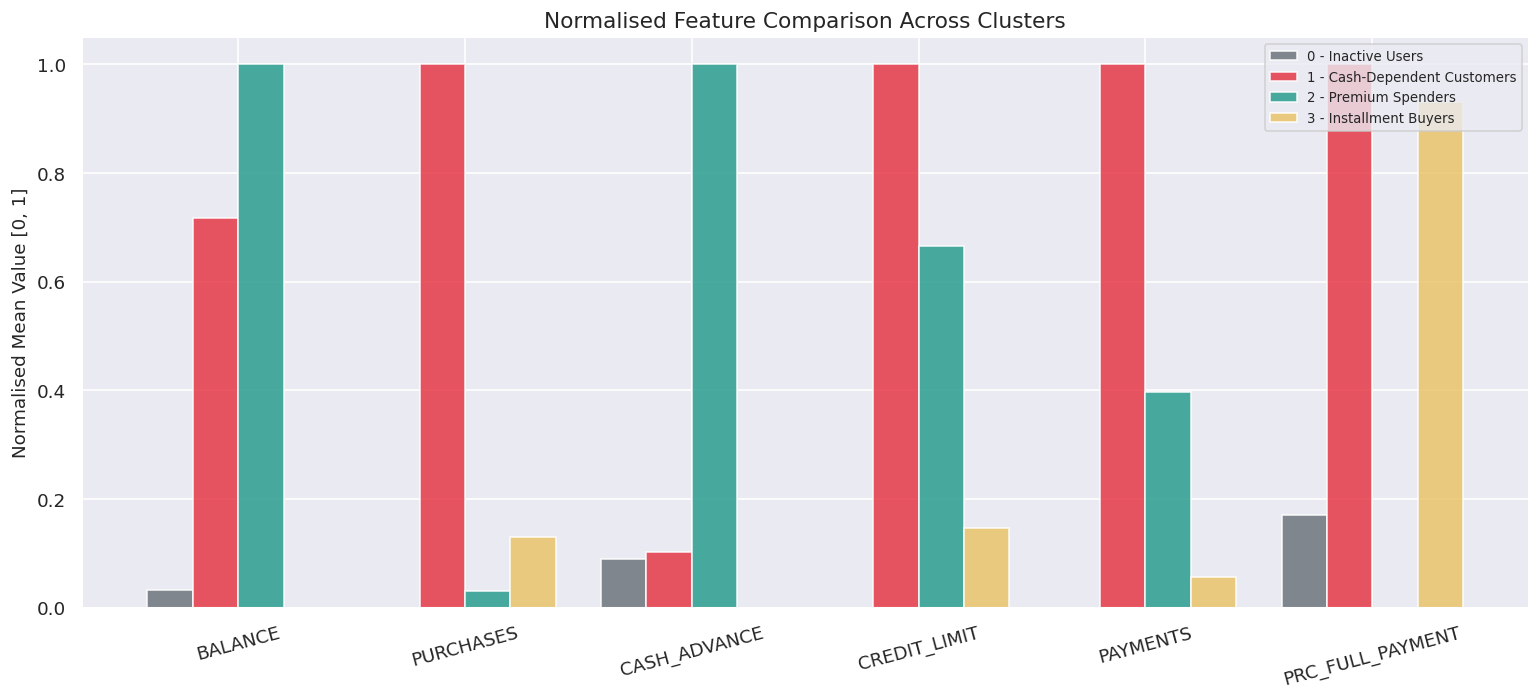

In [22]:
# Normalised feature comparison across clusters
plot_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT']

profile_norm = cluster_profiles[plot_features].copy()
for col in plot_features:
    col_min, col_max = profile_norm[col].min(), profile_norm[col].max()
    if col_max != col_min:
        profile_norm[col] = (profile_norm[col] - col_min) / (col_max - col_min)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(plot_features))
width = 0.2

for i, (idx, row) in enumerate(profile_norm.iterrows()):
    ax.bar(x + i * width, row.values, width, label=idx, color=palette[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(plot_features, rotation=15)
ax.set_title('Normalised Feature Comparison Across Clusters', fontsize=13)
ax.set_ylabel('Normalised Mean Value [0, 1]')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

## 10. Save Models

In [23]:
joblib.dump(kmeans_model, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('Models saved:')
print('  kmeans_model.pkl')
print('  scaler.pkl')
print(f'\nFinal KMeans K=4 Silhouette Score: {kmeans_sil:.4f}')

Models saved:
  kmeans_model.pkl
  scaler.pkl

Final KMeans K=4 Silhouette Score: 0.1977
